# **Práctica 5 - Bioseñales**

**Nombres:**

- Mariana Fernández Prieto
- Isabella Quinchanegua Murillo

### **Resumen**

En este trabajo se realizó el análisis de señales en el dominio de la frecuencia utilizando la Transformada de Fourier. Inicialmente, se generó y analizó una señal compuesta por diferentes componentes sinusoidales, aplicando la Transformada Rápida de Fourier (FFT) para identificar las frecuencias presentes y posteriormente la Transformada Inversa de Fourier (IFFT) para reconstruir la señal original. Además, se implementaron procedimientos de filtrado en frecuencia para extraer componentes específicas y analizar el efecto de los filtros sobre la señal. Estos primeros procedimientos dieron los pasos de procesamiento para las señales de los siguientes puntos.

Después, se trabajó con señales de ECG, aplicando el método de Welch para estimar la densidad espectral de potencia (PSD). Se utilizó una ventana Hanning con solapamiento entre segmentos para obtener una representación espectral más estable. Asimismo, se implementó un filtro pasa bajas mediante FFT para eliminar componentes de alta frecuencia asociadas al ruido de la red eléctrica, reconstruyendo finalmente la señal filtrada mediante la IFFT.

Finalmente, se realizó un análisis espectral de señales EEG correspondientes a un sujeto sano y un paciente con enfermedad de Parkinson. Para ello, se seleccionó el canal Cz debido a su ubicación sobre la corteza motora central y su capacidad para captar la actividad de ambos hemisferios cerebrales. A partir de la PSD obtenida mediante el método de Welch, se comparó la distribución de potencia entre ambas señales, observando las principales diferencias en la concentración energética.

### **Desarrollo práctico**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import find_peaks, welch, windows
from scipy.io import loadmat

**1. Crear señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 
80 y 160 Hz.** 

Para hallar la frecuencia de muestreo ($f_s$) se empleó el teorema de muestreo de Nyquist, el cual indica que la $f_s$ debe ser al menos el doble de la frecuencia máxima presente en la señal. Esto se hace con el fin de evitar el fenómeno de aliasing y garantizar una adecuada reconstrución de la señal original [1].

<center> 

$$ 
f_s > 2 f_{max} 
$$ 

</center>


En este caso, la frecuancia más alta es de 160 Hz, por lo que se obtiene:


<center> 

$$ 
f_s > 2 \cdot 160 = 320 \, Hz 
$$ 

</center>

La señal generada es:

<center> 

$$ 
x(t) = \sin(2\pi \cdot 40t) + \sin(2\pi \cdot 80t) + \sin(2\pi \cdot 160t) 
$$ 

</center>

Se decidió representar gráficamente 10 períodos de la señal con el fin de visualizar adecuadamente su comportamiento temporal. El periodo de una señal compuesta corresponde al mínimo común múltiplo de los periodos individuales; en este caso :

<center> 

$$
T_1 = \frac{1}{40} = 0.025 \, s  
\qquad
T_2 = \frac{1}{80} = 0.0125 \, s  
\qquad
T_3 = \frac{1}{160} = 0.00625 \, s
$$

</center>

<center> 

$$
T_{compuesta} = 0.025 \, s
$$

</center>

Frecuencia minima de muestreo: 320 Hz


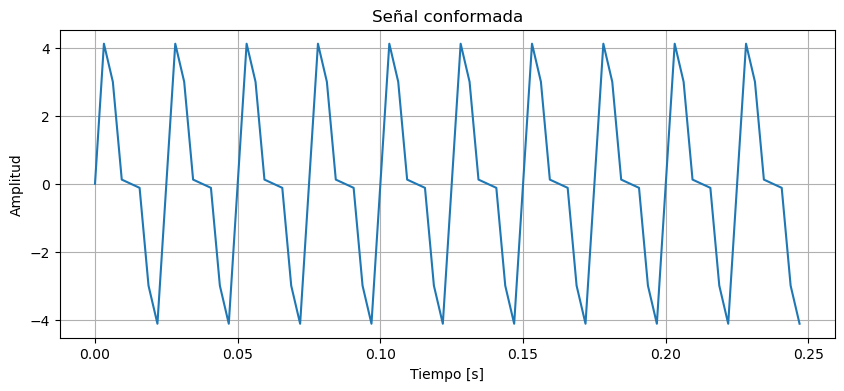

In [2]:
# Frecuencias de las componentes
f1 = 40
f2 = 80
f3 = 160

# Frecuencia máxima
fmax = max([f1, f2, f3])

# Frecuencia de muestreo mínima (Nyquist)
fs_min = 2 * fmax

# Duración
T = 0.25   # 10 periodos de la señal

# Vector de tiempo (fs mínima)
t_fs_min = np.arange(0, T, 1/fs_min)

# Señal
x_fs_min = (3*np.sin(2*np.pi*f1*t_fs_min) +
     2*np.sin(2*np.pi*f2*t_fs_min) +
     1*np.sin(2*np.pi*f3*t_fs_min))

print("Frecuencia minima de muestreo:", fs_min, "Hz")

# Gráfica de la señal con la fs mínima
plt.figure(figsize=(10,4))
plt.plot(t_fs_min, x_fs_min)
plt.title("Señal conformada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

La gráfica presenta variaciones rápidas y cambios bruscos en el tiempo, lo que indica que trabajar con la fs mínima hallada no es suficiente para representar el comportamiento de la señal original. Por lo tanto, se aumentó la frecuencia de muestreo para obtener una representación más precisa.

<center>

$$ 
f_s = 5000 \, Hz 
$$

<center>

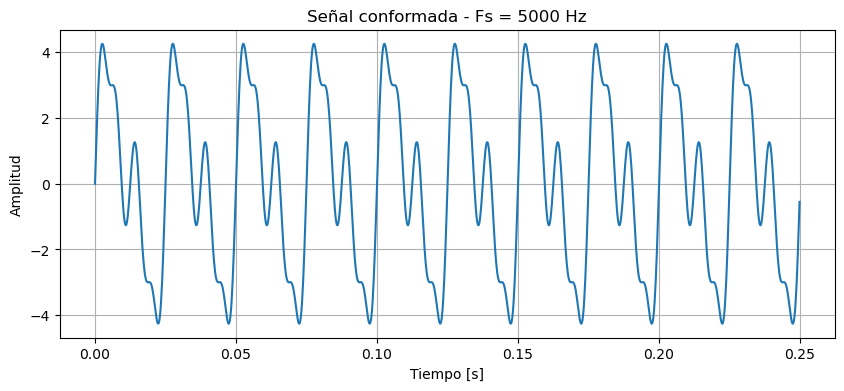

In [3]:
# Se selecciona una mejor frecuencia de muestreo
Fs = 5000

# Vector de tiempo (fs nueva)
t = np.arange(0, T, 1/Fs)

# Señal
x = (3*np.sin(2*np.pi*f1*t) +
     2*np.sin(2*np.pi*f2*t) +
     1*np.sin(2*np.pi*f3*t))

# Gráfica de la señal con la fs mínima
plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Señal conformada - Fs = 5000 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

**2. Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia.**

La Transformada Discreta de Fourier (DFT) transforma una señal en el dominio del tiempo al dominio de la frecuencia, con el fin de identificar las componentes frecuenciales que conforman la señal.

Para calcular la DFT, se empleó el algoritmo de la Transformada Rápida de Fourier (FFT). El resultado obtenido (X(k)) contiene información sobre la amplitud y fase de cada frecuencia presente en la señal [2].

La relación entre los índices de la FFT y las frecuencias reales se obtiene mediante [2]:

<center>

$$
F = \frac{k \cdot F_s}{N}
$$

</center>	​

donde:
- k corresponde al índice de la FF
- N es el número total de muestras

Para graficar el espectro de frecuencia, se hallaron las magnitudes correspondientes a cada componente frecuencial de la señal. 

En el análisis espectral, se utilizaron únicamente las componentes de frecuencia positivas debido a que la señal analizada es real. Por las propiedades de la FFT, toda señal real presenta simetría conjugada, decir que, la mitad negativa del espectro contiene la misma información que la mitad positiva [2]. Esta propiedad se expresa como:

<center>

$$
X(-f) = X^*(f)
$$

</center>

Esto minimiza la repeticiçon de datos y facilita la visualización e interpretación de las frecuencias presentes en la señal.

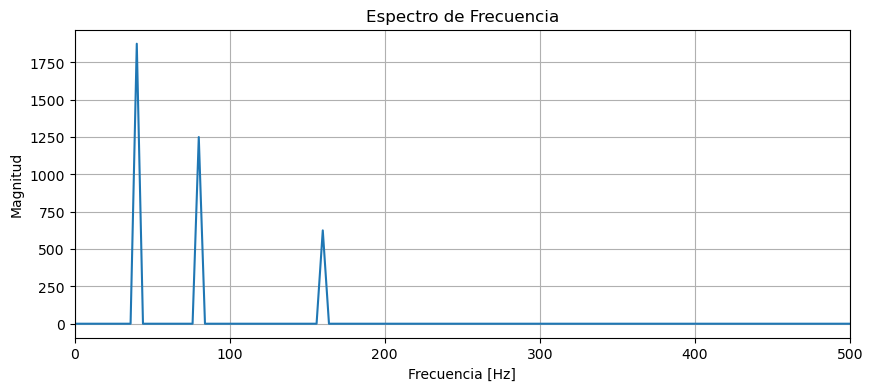

In [4]:
# Número total de muestras
N = len(x)

# Cálculo de la DFT
X = np.fft.fft(x)

# Frecuencias reales
F = np.arange(0, N) * Fs / N

# Mitad positiva
Nmitad = N // 2
Fmitad = F[:Nmitad] # Frecuencias de la mitad positiva
Mmitad = np.abs(X[:Nmitad]) # Magnitud de la DFT

# Grafica FFT
plt.figure(figsize=(10,4))
plt.plot(Fmitad, Mmitad) #Gráfica mitad positiva
plt.title("Espectro de Frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim([0,500]) # Mostrar hasta 500 Hz - Mejor visualización
plt.grid()
plt.show()

In [5]:
# Encontrar picos (índice)
picos, propiedades = find_peaks(Mmitad, height=50)

# Frecuencias de los picos
frecuencias_picos = Fmitad[picos]

# Magnitudes de los picos
magnitudes_picos = Mmitad[picos]

print("Picos espectrales principales:")

for i in range(len(picos)):
    
    print(f"\nPico {i+1}")
    print(f"Frecuencia: {frecuencias_picos[i]:.2f} Hz")
    print(f"Magnitud : {magnitudes_picos[i]:.2f}")

Picos espectrales principales:

Pico 1
Frecuencia: 40.00 Hz
Magnitud : 1875.00

Pico 2
Frecuencia: 80.00 Hz
Magnitud : 1250.00

Pico 3
Frecuencia: 160.00 Hz
Magnitud : 625.00


**3. Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier.**

La Transformada Inversa de Fourier (IFFT) permite reconstruir una señal en el dominio del tiempo a partir de las componentes frecuenciales obtenidas mediante la FFT [3]. En Python, la operación se realiza mediante:

np.fft.ifft(X)

donde X corresponde al espectro frecuencial calculado previamente con la FFT.

Se grafica la señal original con la señal reconstruida para comparar y verificar que la DFT y la IFFT conservan adecuadamente la información de la señal. 

c:\Users\isaqm\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\isaqm\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


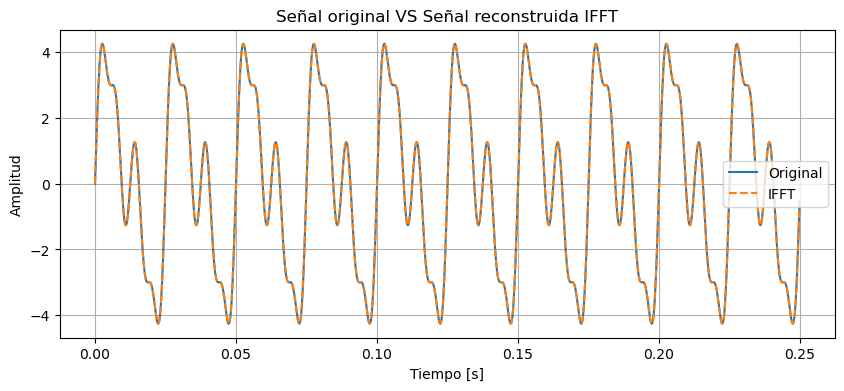

In [6]:
# Cálculo de la IFFT
x_ifft = np.fft.ifft(X)

# Gráfica comparación: Señal original VS Señal reconstruida con IFFT
plt.figure(figsize=(10,4))
plt.plot(t, x, label = 'Original') # Señal original # Señal reconstruida con IFFT
plt.plot(t, x_ifft, '--', label = 'IFFT')
plt.title("Señal original VS Señal reconstruida IFFT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

Al observar ambas gráficas, se evidencia que la señal reconstruida coincide con la señal original, demostrando que el proceso de transformación y reconstrucción fue realizado adecuadamente.

**4. ¿Se podría decir que las siguientes líneas aplican un filtro? ¿Por qué?** 

C:\Users\isaqm\AppData\Local\Temp\ipykernel_7652\3457369438.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13] # Selección de un rango de componentes (9-13) y poniendo los demás valores igual a cero


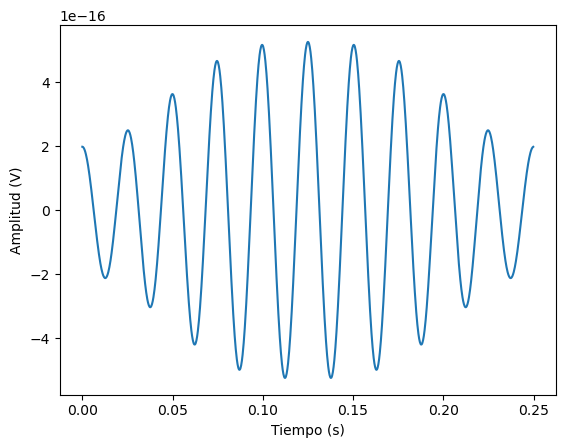

In [7]:
F1 = np.fft.fft(x)  # Cálculo de la DFT
F2 = np.zeros((len(F1))) # Vector de ceros del mismo tamaño del espectro
F2[9:13] = F1[9:13] # Selección de un rango de componentes (9-13) y poniendo los demás valores igual a cero
xr = np.fft.ifft(F2) # Cálculo de la IFFT de la señal del rango seleccionado

# Gráfica de visualización del filtro
fig = plt.figure() 
ax = fig.add_subplot(111) 
ax.plot(t, np.real(xr)) 
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)'); 
plt.show() 

El código calcula la DFT a la señal commpuesta, selecciona solo algunos de los valores calculados y reemplaza el resto por cero. Después, se le aplica la IFFT a este rango y se obtiene una nueva señal que contiene únicamente las frecuencias seleccionadas. 

Esto indica que estas líneas si aplican un filtro debido a que solo conservan una pequeña parte de las frecuencias de la señal original y eliminan las demás componentes frecuenciales. Por lo tanto, el procedimiento funciona como un filtro en el dominio de la frecuencia.

**Extraiga de manera similar cada una de las componentes de la señal.**

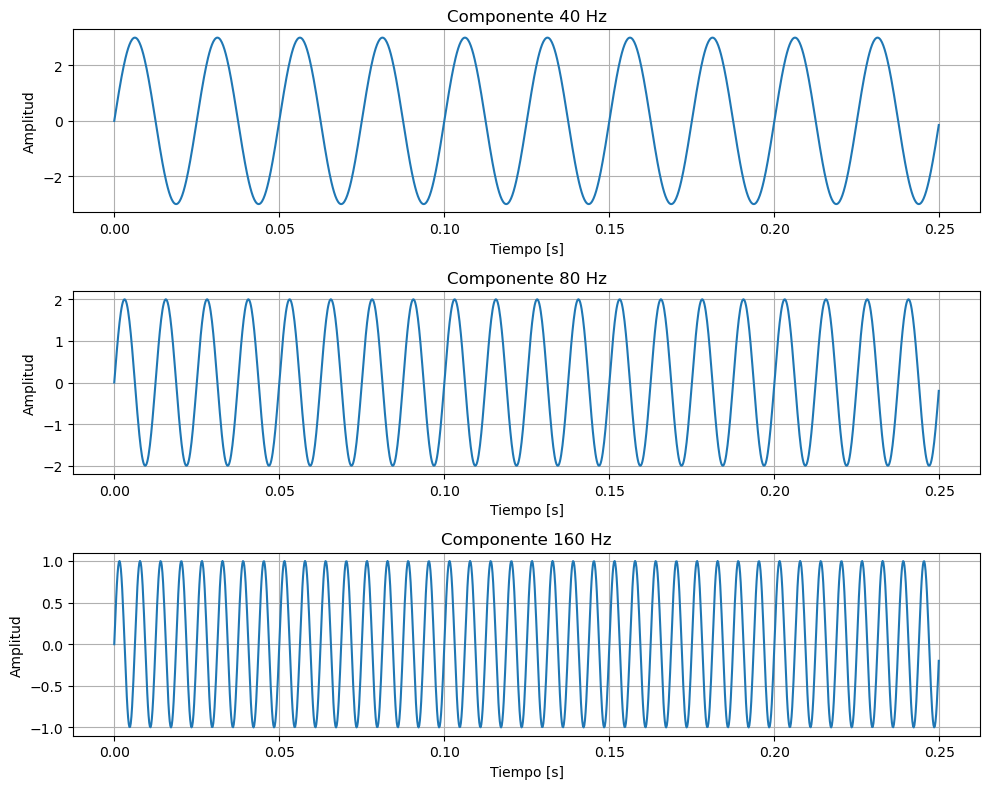

In [8]:
# Extraer señales
def extraer_componentes(f, N, Fs, X, t):

    k = int(f*N/Fs) # Índices k aproximados. Necesarios para definir el rango

    X_ifft = np.zeros(len(X), dtype=complex) #, dtype=complex

    inicio = k-1
    fin = k+2

    X_ifft[inicio:fin] = X[inicio:fin]

    # Parte simétrica negativa
    # Es necesario calcularla para hacer una reconstrucción completa de la señal debido a la simetría conjugada
    X_ifft[-fin:-inicio] = X[-fin:-inicio]

    x = np.fft.ifft(X_ifft)

    plt.plot(t, x)
    plt.title(f"Componente {f} Hz")
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()

# Graficas
plt.figure(figsize=(10,8))

# Gráfica 40 Hz
plt.subplot(3,1,1)
extraer_componentes(f1, N, Fs, X, t)

# Gráfica 80 Hz
plt.subplot(3,1,2)
extraer_componentes(f2, N, Fs, X, t)

# Gráfica 160 Hz
plt.subplot(3,1,3)
extraer_componentes(f3, N, Fs, X, t)

plt.tight_layout()
plt.show()

**5. El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de 
muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas 
de Welch** 

En este punto se realizó un análisis frecuencial de una señal de ECG utilizando el periodograma para identificar el contenido espectral de la señal. Inicialmente, la señal fue cargada desde el archivo senecg.mat y graficada en el dominio del tiempo para observar su comportamiento general.

In [9]:
# Cargar archivo .mat
archivo = loadmat('senecg.mat')

print(archivo.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


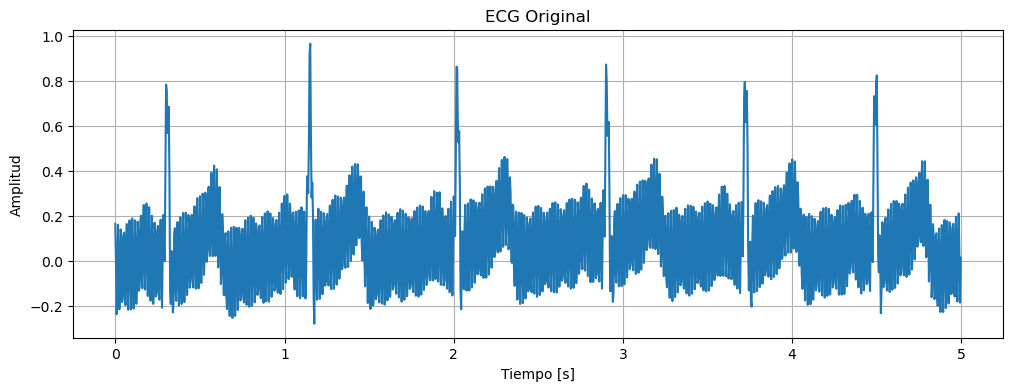

In [10]:
ecg = np.squeeze(archivo['ECG']) #Extracción de los datos de ECG
Fs_ecg = 250 # Hz - Frecuencia de muestreo

t_4 = np.arange(0,(len(ecg)/Fs_ecg),(1/Fs_ecg)) # Vector de tiempo señal ECG

# Señal ECG - Punto 4
plt.figure(figsize=(12,4))
plt.plot(t_4, ecg)
plt.title("ECG Original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

El análisis frecuencial se realizó mediante el método de Welch con el objetivo de estimar la densidad espectral de potencia (PSD) y determinar la presencia de ruido. Este método divide la señal en varios segmentos, calcula el periodograma de cada uno y promedia los resultados, obteniendo una estimación espectral más estable y menos sensible al ruido [4]. Para este cálculo se empleó una ventana Hanning y un solapamiento del 50% entre segmentos. 

La ventana de Hanning se aplica a cada uno de los segmentos de la señal. Esta atenua suavemente los extremos de cada tramo hasta cero, lo que evita cambios abruptos generados al dividir los datos. Esto garantiza que, al promediar todos los segmentos, el PSD resultante sea mucho más limpio [5].

Además, se seleccionó una ventana de 256 muestras debido a que este tamaño proporciona un equilibrio adecuado entre resolución temporal y resolución frecuencial en el análisis espectral del ECG [6]. Ventanas muy pequeñas generan una baja resolución en frecuencia, dificultando diferenciar componentes espectrales cercanas, mientras que ventanas demasiado grandes reducen la resolución temporal y aumentan el costo computacional [7]. 

Finalmente, el solapamiento del 50% (128 muestras) se usó para mejorar la continuidad entre los segmentos de la señal, reduciendo la variabilidad entre periodogramas y obteniendo una PSD más suave y estable [8].

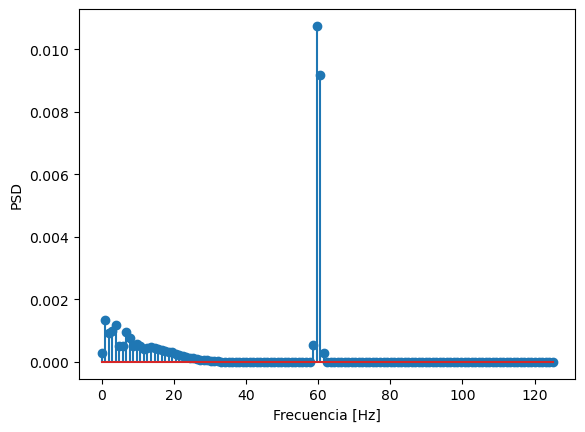

In [11]:
# Periodograma de Welch

nperseg = 256 # Ancho de la ventana
noverlap = int(nperseg/2) # Solapamiento de las ventanas
f, Pxx = welch(np.real(ecg), Fs_ecg, 'hann', nperseg, noverlap)

# Gráfica frecuencia VS potencia
plt.stem(f, Pxx)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.show()

En la gráfica se evidencia un incremento significativo de potencia alrededor de 60 Hz, lo que indica la presencia de ruido asociado a la red eléctrica, generando altas distorsiones en la señal ECG [9].

La mayor parte de la información fisiológica del ECG, incluyendo onda P, complejo QRS y onda T, se encuentra concentrada aproximadamente entre 0.05 Hz y 40 Hz [9]. Debido a esto, se apicó un filtro pasa bajas en el dominio de la frecuencia mediante la DFT (proceso mostrado anteriormente), donde se eliminaron las frecuencias superiores a 40 Hz. El filtrado permite mejorar la calidad de la señal al conservar únicamente las componentes cardíacas relevantes y atenuar las frecuencias asociadas al ruido. 

In [41]:
# Filtrado ECG

# 1. FFT
ecg_fft = np.fft.fft(ecg) # Cálculo de la DFT

N_ecg = len(ecg_fft) # Numero de muestras

k40_ecg = int(40*N_ecg/Fs_ecg) # Indice correspondiente a 40 Hz

ecg_filt = np.zeros(N_ecg, dtype=complex) # Vector de ceros del mismo tamaño del espectro

# Conservar únicamente frecuencias de 0-40 Hz
ecg_filt[0:k40_ecg] = ecg_fft[0:k40_ecg]

Se aplicó la IFFT para reconstruir la señal filtrada y comparar su comportamiento con la señal original, verificando que se conservara la información de interés.

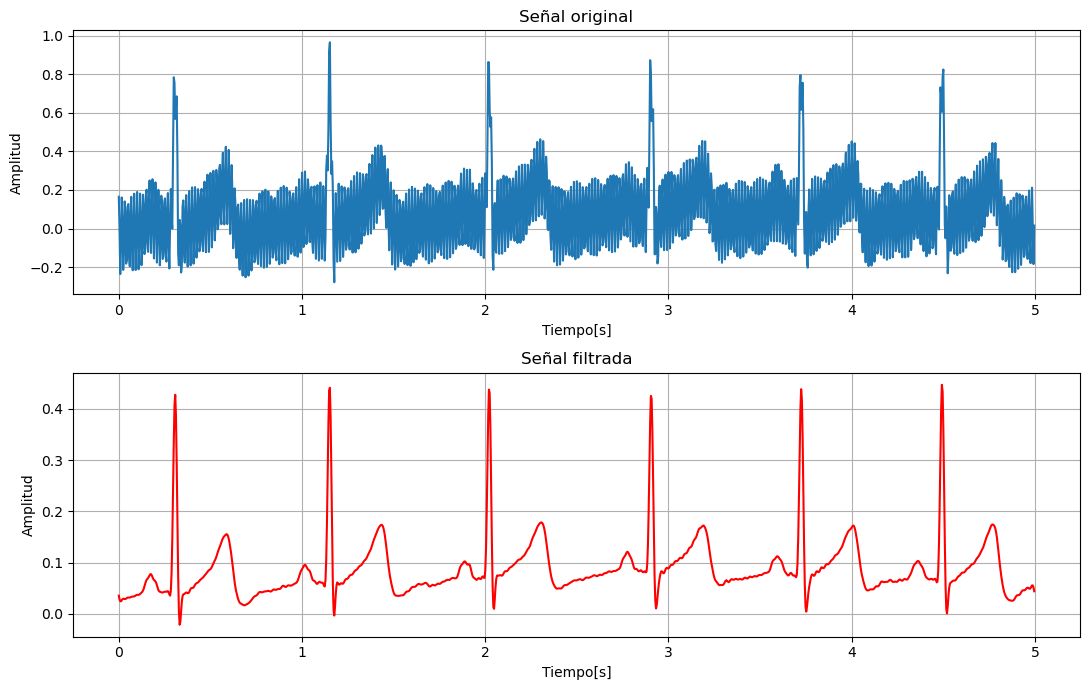

In [43]:
# 2. IFFT
ecg_filtrado = np.fft.ifft(ecg_filt)

# Graficar comparación

# Señal original
plt.figure(figsize=(11,7))
plt.subplot(2,1,1)
plt.plot(t_4, ecg)
plt.title("Señal original")
plt.xlabel("Tiempo[s]")
plt.ylabel("Amplitud")
plt.grid()

# Señal filtrada
plt.subplot(2,1,2)
plt.plot(t_4, np.real(ecg_filtrado), color = 'r')
plt.title("Señal filtrada")
plt.xlabel("Tiempo[s]")
plt.ylabel("Amplitud")
plt.grid()

plt.tight_layout()
plt.show()

Se confirma que efectivamente se eliminó el ruido de la señal y se conservó la información de importancia.

Finalmente, se graficó el periodograma despúes del filtrado, con el fin de comprobar que las altas frecuencias fueron atenuadas y que el contenido espectral quedó concentrado en las frecuencias asociadas al ECG.

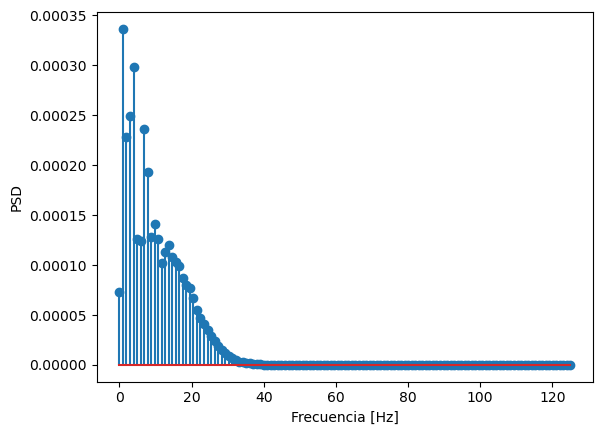

In [35]:
# 3. Periodograma de Welch - ECG filtrado

f2, Pxx2 = welch(np.real(ecg_filtrado), Fs_ecg, 'hann', nperseg, noverlap)

# Gráfica frecuencia VS potencia
plt.stem(f2, Pxx2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.show()

Se evidencia que se atenuaron de forma eficaz las frecuencias por encima de 40 Hz, dado que ya no se observan los picos de potencia alrededor de 60 Hz.

**6. Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG 
de un paciente Sano y otra de un paciente con Parkinson de algún canal que presente diferencias. Realice un análisis comparativo de las señales en base a los 
periodogramas.** 

En este punto se realizó un análisis espectral de unas señales EEG correspondientes a un paciente sano y a un paciente con Parkinson mediante el método de Welch, con el objetivo de comparar la PSD en frecuencia entre ambas señales.

Se seleccionaron dos archivos de la base de datos "datos_senales_datos_parkinson_cursos"; "C021_EP_reposo.mat" para los datos del sujeto sano y "P030_EP_reposo.mat" para los datos del paciente con Parkinson.

In [44]:
sano = loadmat("C021_EP_reposo.mat")
parkinson = loadmat("P030_EP_reposo.mat")

print(sano.keys())
print(parkinson.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])
dict_keys(['__header__', '__version__', '__globals__', 'data'])


Se extrajeron los datos de los archivos y se verificó el tamaño de la matriz.

In [45]:
eeg_sano = sano['data']
eeg_parkinson = parkinson['data']

print("Forma datos sano:", eeg_sano.shape)
print("Forma datos parkinson:", eeg_parkinson.shape)

Forma datos sano: (8, 2000, 180)
Forma datos parkinson: (8, 2000, 171)


Los datos de cada sujeto están distribuidos de la siguiente manera: 8 filas, que corresponden a los canales; 2000 columnas, que corresponden a los datos; y una tercera dimensión que corresponde a las épocas o ensayos registrados para cada sujeto. La frecuencia de muestreo fue de 1000 Hz.

Los canales registrados fueron: 'C3' 'C1' 'CZ' 'C2' 'C4' 'O1' 'OZ' 'O2'. Las filas se encuentran en ese mismo orden.

Recientes investigaciones reportan que los electrodos centrales C3, CZ y C4 presentan patrones espectrales característicos en pacientes con Parkinson, que permiten diferenciar sujetos sanos y pacientes mediante la PSD y actividad oscilatoria cortical [10]. Para este trabajo, se eligió el canal Cz debido a que se encuentra ubicado sobre la región motora central y, al estar sobre la línea media, permite captar actividad de ambos hemisferios, proporcionando una representación general de la actividad cortical asociada al control del movimiento.

Se realizó un promedio de los ensayos del canal seleccionado con el fin de obtener una señal representativa de la actividad cerebral y reducir la influencia de ruido y variaciones presentes entre las épocas individuales.

Para el cálculo del periodograma de Welch se utilizó una ventana Hanning, con un ancho de 1024 muestras. Dado a que la señal EEG posee una frecuencia de muestreo de 1000 Hz, se requiere una ventana mayor para obtener una adecuada resolución frecuencial al analizar las bandas cerebrales.

De igual manera, se empleó un solapamiento del 50% entre ventanas para mejorar la continuidad entre segmentos consecutivos y obtener una estimación de la PSD más estable, reduciendo las fluctuaciones en el espectro [11].

In [72]:
# Canal a usar: Canal Cz
canal = 2 # Cz

# Promedio sobre épocas
senal_sano = np.mean(eeg_sano[canal, :, :], axis=1)
senal_parkinson = np.mean(eeg_parkinson[canal, :, :], axis=1)

# Frecuencia de muestreo
Fs_eeg = 1000

# Parámetros para el periodograma de Welch
nperseg = 1024  # Ancho de la ventana
solap = nperseg // 2 # Solapamiento del 50%

# Aplicar método de Welch con ventana Hann
f_sano, Pxx_sano = welch(senal_sano, fs = Fs_eeg, window='hann', nperseg = nperseg, noverlap = solap)
f_par, Pxx_par = welch(senal_parkinson, fs = Fs_eeg, window='hann', nperseg = nperseg, noverlap = solap)

Se graficó la PSD del sujeto sano y el paciente con Parkinson en el canal Cz. 

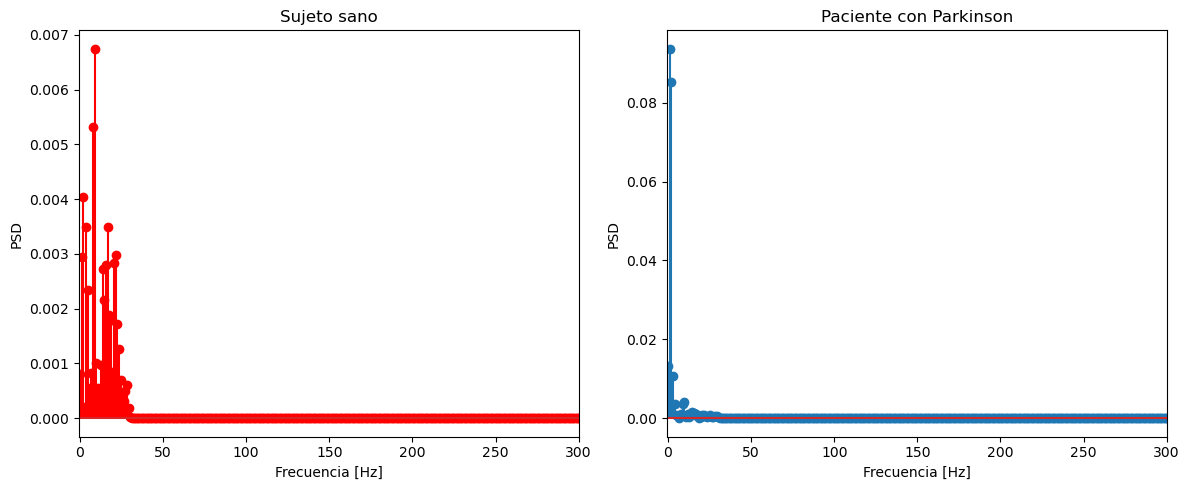

In [76]:
# Gráfica frecuencia VS potencia: Sujeto sano y paciente con Parkinson

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.stem(f_sano, Pxx_sano, linefmt = "r")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title("Sujeto sano")
plt.xlim(-0.5,300)

plt.subplot(1,2,2)
plt.stem(f_par, Pxx_par)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title("Paciente con Parkinson")
plt.xlim(-0.5,300)

plt.tight_layout()
plt.show()

En ambos casos, la mayor parte de la energía de la señal se encuentra concentrada en bajas frecuencias, un comportamiento típico de señales EEG dado que las señales suelen oscilar entre 0 - 35 Hz [11]. Sin embargo, el paciente con Parkinson presenta valores de potencia considerablemente más altos en las frecuencias bajas en comparación con el sujeto sano, evidenciando una mayor concentración energética.

El paciente con Parkinson muestra picos de potencia dominante más altos pero concentrados en un menor número de frecuencias, mostrando una actividad cerebral dominante en bandas específicas. Esto ocurre porque la enfermedad produce alteraciones en las oscilaciones neuronales de regiones motoras, lo que genera una sincronización excesiva de la actividad cerebral en determinadas bandas [11].

Por otro lado, el sujeto sano presenta una distribución de potencia más dispersa y uniforme entre diferentes frecuencias. Esto indica un funcionamiento cerebral más equilibrado y dinámico, donde las neuronas tienen patrones de activación más variados.

### **Conclusiones**

1. La Transformada de Fourier (DFT) y la Transformada Inversa de Fourier (IFFT) permitieron analizar y reconstruir señales en el dominio del tiempo y la frecuencia, demostrando que es posible identificar y filtrar componentes frecuenciales específicas conservando la información principal de la señal original.

2. El método de Welch resultó adecuado para la estimación de la densidad espectral de potencia (PSD) en señales biomédicas como ECG y EEG, debido a que proporciona una representación espectral más estable y menos sensible al ruido mediante el uso de ventanas y solapamiento entre segmentos.

3. El análisis espectral de las señales EEG permitió evidenciar diferencias en la distribución de potencia entre un sujeto sano y un paciente con Parkinson, observando una mayor energía en la persona enferma, lo que refleja alteraciones en la actividad cortical asociadas a la patología.

### **Referencias**

[1] Adquirir una señal analógica: ancho de banda, teorema de muestreo de Nyquist y aliasing. (2006, 31 agosto). NI. https://www.ni.com/es/shop/data-acquisition/measurement-fundamentals/analog-fundamentals/acquiring-an-analog-signal--bandwidth--nyquist-sampling-theorem-.html?srsltid=AfmBOoqGbFEZ43sFutNdil7roJpTHOuL65bvLVmV0P-V5bqNP1I6dbg2

[2] Selesnick, I. W., & Schuller, G. (2001). The Discrete Fourier Transform. En K. R. Rao & P. C. Yip (Eds.), The Transform and Data Compression Handbook (pp. 37–78). CRC Press. https://dsp-book.narod.ru/TDCH/CH-02.PDF

[3] Numpy.fft.ifft — NumPY v2.4 Manual. (s. f.). https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html

[4] Adarsh, C., & Kiranmayi, G. R. (2024). ECG Signal Analysis for the Detection of Myocardial Infarction. IEEE, 1-5. https://doi.org/10.1109/icsses62373.2024.10561288

[5] Entender la ventana de Hanning: una guía práctica para principiantes. (2024, 14 noviembre). Wray Castle. https://wraycastle.com/es/blogs/knowledge-base/hanning-window

[6] Patrick McSharry (ed.), Advanced Methods and Tools for ECG Data Analysis, Artech House, 2006. https://www.globalspec.com/reference/57648/203279/3-2-spectral-and-cross-spectral-analysis-of-the-ecg

[7] Jwo, D., Chang, W., & Wu, I. (2021). Windowing Techniques, the Welch Method for Improvement of Power Spectrum Estimation. Computers, Materials & Continua/Computers, Materials & Continua (Print), 67(3), 3983-4003. https://doi.org/10.32604/cmc.2021.014752

[8] MathWorks. (s.f.). pwelch - Welch's power spectral density estimate. MATLAB Help Center, de https://la.mathworks.com/help/signal/ref/pwelch.html

[9] Xie, L., Li, Z., Zhou, Y., He, Y., & Zhu, J. (2020). Computational Diagnostic Techniques for Electrocardiogram Signal Analysis. Sensors, 20(21), 6318. https://doi.org/10.3390/s20216318

[10] Lensky, A. (2025). Oscillatory Signatures of Parkinson’s Disease: Central and Parietal EEG Alterations Across Multiple Frequency Bands. arXiv (Cornell University). https://doi.org/10.48550/arxiv.2503.12392

[11] Cohen, S. L., Choi, J. W., Toga, A. W., Pouratian, N., & Duncan, D. (2023). Exaggerated High-Beta Oscillations are Associated with Cortical Thinning at the Motor Cortex in Parkinson’s Disease. IEEE, 2023, 1-4. https://doi.org/10.1109/embc40787.2023.10341040